F1スコア: 0.7424 (正解数: 145/179件)


/Users/f-kazuma/Developer/Python_seminer/8th/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/8th/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/8th/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/Developer/Python_seminer/8th/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/f-kazuma/

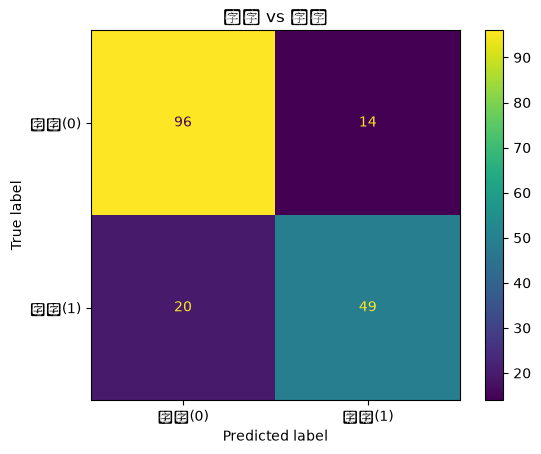

0.7424242424242424

In [2]:
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def result(y_pred, y_answer):
    # IDの過不足チェック
    missing = set(y_answer['PassengerId']) - set(y_pred['PassengerId'])
    extra = set(y_pred['PassengerId']) - set(y_answer['PassengerId'])
    if missing:
        print(f"⚠️ 未提出のID: {len(missing)}件")
    if extra:
        print(f"⚠️ 想定外のID: {len(extra)}件")

    # PassengerIdで突き合わせ
    merged = y_answer.merge(y_pred, on='PassengerId', suffixes=('_true', '_pred'))

    f1 = f1_score(merged['Survived_true'], merged['Survived_pred'])
    correct = (merged['Survived_true'] == merged['Survived_pred']).sum()
    print(f"F1スコア: {f1:.4f} (正解数: {correct}/{len(merged)}件)")
    
    cm = confusion_matrix(merged['Survived_true'], merged['Survived_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['死亡(0)', '生存(1)']).plot()
    plt.title('予測 vs 正解')
    plt.show()

    return f1

# --- 使う側 ---
y_answer = pd.read_csv('test_titanic.csv')  # 自分だけが持つ模範解答

y_pred = pd.read_csv('pysemi8_xgboost_predictions.csv')
result(y_pred, y_answer)